In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
# Load The Data
columns = ['count', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek','hour']

In [23]:
#df = pd.read_csv('bike_Sharing_data/train.csv')
df = pd.read_csv('BikeSharingData.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [24]:
## EDA

In [27]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
# We need to convert datetime to numeric for training.
# Let's extract key features into separate numeric columns
def add_features(df):
    df['month'] = pd.to_datetime(df['datetime']).dt.month
    df['Year'] = pd.to_datetime(df['datetime']).dt.year
    df['Day'] = pd.to_datetime(df['datetime']).dt.day
    df['Hour'] = pd.to_datetime(df['datetime']).dt.hour
    return df

In [7]:
df = add_features(df)
#add_features(df_test)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,2011,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,2011,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2011,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,2011,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,2012,19,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,2012,19,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,2012,19,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12,2012,19,22


In [8]:
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.dayofweek
days = {0:'Mon',1:'Tue',2:'Wed',3:'Thur',4:'Fri',5:'Sat',6:'Sun'}
df['day_of_week'] = df['day_of_week'].apply(lambda x: days[x])
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,2011,1,0,Sat
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,2011,1,1,Sat
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2011,1,2,Sat
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,2011,1,3,Sat
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,2011,1,4,Sat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,2012,19,19,Wed
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,2012,19,20,Wed
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,2012,19,21,Wed
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12,2012,19,22,Wed


In [9]:
import calendar
df['month'] = df['month'].apply(lambda x: calendar.month_abbr[x])
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Jan,2011,1,0,Sat
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Jan,2011,1,1,Sat
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,Jan,2011,1,2,Sat
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,Jan,2011,1,3,Sat
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,Jan,2011,1,4,Sat


In [10]:
print(df['month'].value_counts())
print(df['day_of_week'].value_counts())

Jul    912
May    912
Dec    912
Jun    912
Aug    912
Nov    911
Oct    911
Apr    909
Sep    909
Mar    901
Feb    901
Jan    884
Name: month, dtype: int64
Sat     1584
Sun     1579
Thur    1553
Wed     1551
Mon     1551
Tue     1539
Fri     1529
Name: day_of_week, dtype: int64


In [11]:
# Working day usage
df['workingday'].value_counts()

1    7412
0    3474
Name: workingday, dtype: int64

In [12]:
df['weather'].value_counts()

1    7192
2    2834
3     859
4       1
Name: weather, dtype: int64

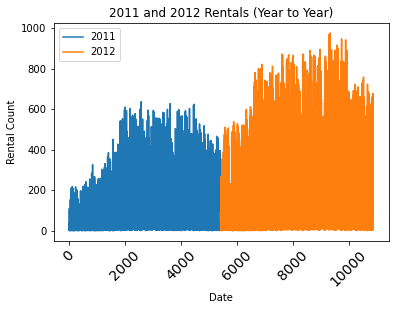

In [13]:
#plt.plot(df['2011']['count'],label='2011')


plt.plot(df[df['Year'] == 2011]['count'] , label = '2011')
plt.plot(df[df['Year'] == 2012]['count'] , label = '2012')
plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('2011 and 2012 Rentals (Year to Year)')
plt.legend()
plt.show()

In [14]:
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Jan,2011,1,0,Sat
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Jan,2011,1,1,Sat


In [15]:
#df['date'] = pd.to_datetime(df['datetime']).dt.month
df['date'] = pd.to_datetime(df['datetime']).dt.date
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week,date
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Jan,2011,1,0,Sat,2011-01-01
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Jan,2011,1,1,Sat,2011-01-01
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,Jan,2011,1,2,Sat,2011-01-01
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,Jan,2011,1,3,Sat,2011-01-01
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,Jan,2011,1,4,Sat,2011-01-01


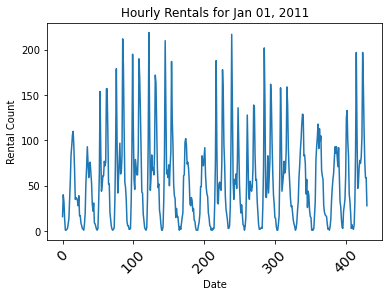

In [16]:

# Rentals change hourly!
plt.plot(df[(df['Year'] == 2011) & (df['month'] == 'Jan')]['count'])
plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('Hourly Rentals for Jan 01, 2011')
plt.show()

In [17]:
monthrange  = df['month']
monthrange = list(set(monthrange))

In [18]:
monthrange

['Apr',
 'Nov',
 'Dec',
 'Mar',
 'Jun',
 'Jan',
 'Sep',
 'May',
 'Oct',
 'Jul',
 'Aug',
 'Feb']

No handles with labels found to put in legend.


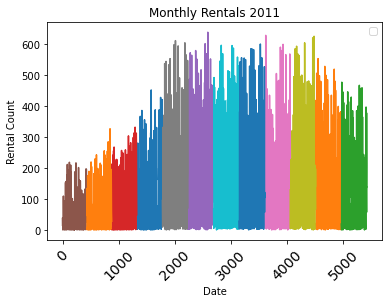

In [19]:
""" Monthly  review"""

# Rentals change hourly!
for each in monthrange:
    plt.plot(df[(df['Year'] == 2011) & (df['month'] == each)]['count'])

plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('Monthly Rentals 2011')
plt.legend()
plt.show()

For the Month Apr


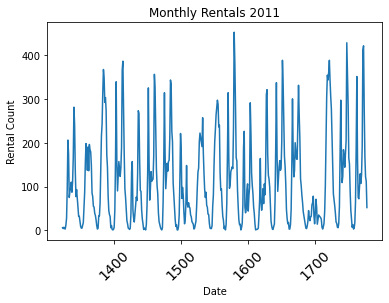

For the Month Nov


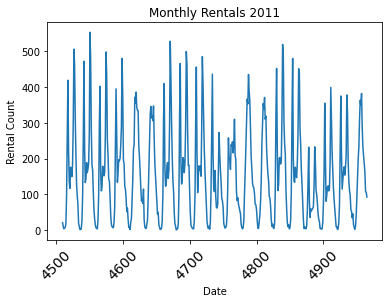

For the Month Dec


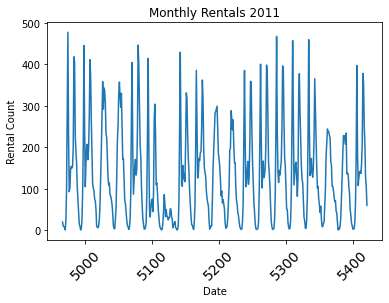

For the Month Mar


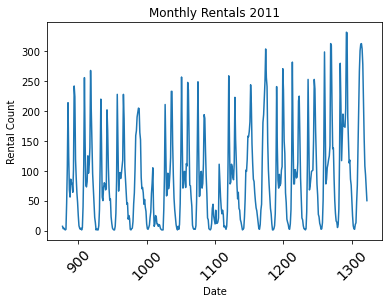

For the Month Jun


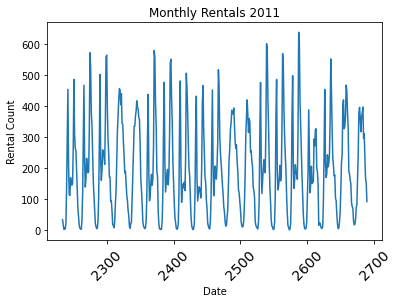

For the Month Jan


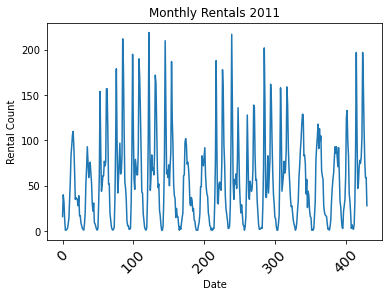

For the Month Sep


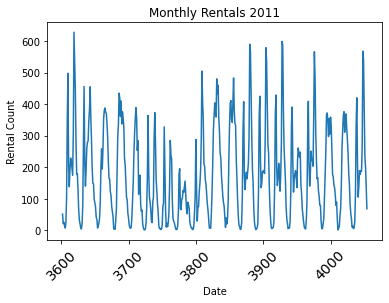

For the Month May


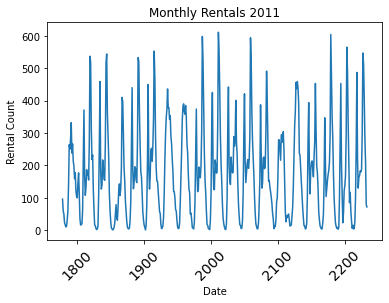

For the Month Oct


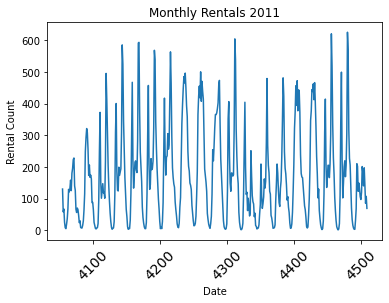

For the Month Jul


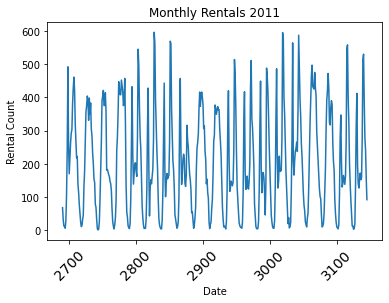

For the Month Aug


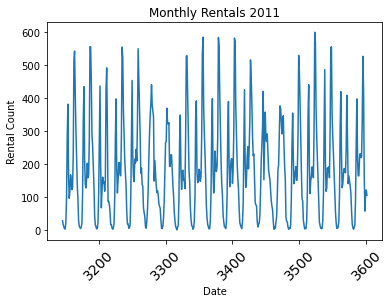

For the Month Feb


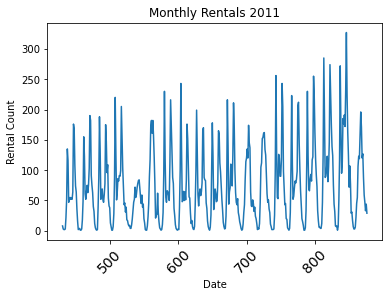

In [20]:
""" Monthly  review"""

# Rentals change hourly!
for each in monthrange:
    print("For the Month", each)
    plt.plot(df[(df['Year'] == 2011) & (df['month'] == each)]['count'])
    plt.xticks(fontsize=14, rotation=45)
    plt.xlabel('Date')
    plt.ylabel('Rental Count')
    plt.title('Monthly Rentals 2011')
    plt.show()